# Task 5: 模型评估与选择 (Model Evaluation & Selection)

**Student Dropout and Academic Success Dataset**

本 Notebook 涵盖以下内容 / This notebook covers:
1. 重新训练基础模型 / Retrain baseline models
2. 计算详细指标 (accuracy, precision, recall, F1) / Calculate detailed metrics
3. 绘制 ROC 曲线并计算 AUC / Plot ROC curves and calculate AUC
4. 交叉验证改进模型 / Improve models via cross-validation
5. 验证曲线分析 (过拟合/欠拟合) / Validation curve analysis (overfitting/underfitting)
6. 综合讨论 / Comprehensive discussion

In [1]:
import sys
import os

# 添加项目根目录到路径 / Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.prediction import train_model, predict_and_evaluate, get_model
from src.evaluation import (
    calculate_metrics,
    plot_roc_curves,
    cross_validate_model,
    plot_validation_curve,
    plot_learning_curve,
    metrics_comparison_table,
)

# 设置绘图风格 / Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

PLOT_DIR = os.path.join(project_root, "data", "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

In [2]:
# 加载工程特征数据 / Load engineered feature data
data_dir = os.path.join(project_root, "data")

X_train = pd.read_csv(os.path.join(data_dir, "features_engineered_train.csv"))
y_train = pd.read_csv(os.path.join(data_dir, "targets_engineered_train.csv")).iloc[:, 0]
X_val = pd.read_csv(os.path.join(data_dir, "features_engineered_val.csv"))
y_val = pd.read_csv(os.path.join(data_dir, "targets_engineered_val.csv")).iloc[:, 0]
X_test = pd.read_csv(os.path.join(data_dir, "features_engineered_test.csv"))
y_test = pd.read_csv(os.path.join(data_dir, "targets_engineered_test.csv")).iloc[:, 0]

# 合并 train+val 用于交叉验证 / Merge train+val for cross-validation
X_trainval = pd.concat([X_train, X_val], ignore_index=True)
y_trainval = pd.concat([y_train, y_val], ignore_index=True)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train+Val (for CV): {X_trainval.shape}")

Train: (2875, 50), Val: (664, 50), Test: (885, 50)
Train+Val (for CV): (3539, 50)


## 1. 重新训练模型并计算详细指标 (Retrain Models & Calculate Detailed Metrics)

使用 NB04 中确定的模型配置重新训练，并计算完整的 precision / recall / F1 指标。
Retrain with model configs from NB04, then calculate full precision / recall / F1 metrics.

In [3]:
# 重新训练三种模型 / Retrain three models
models = {
    "Decision Tree": train_model(X_train.values, y_train.values, "dt", max_depth=10),
    "Logistic Regression": train_model(X_train.values, y_train.values, "lr", max_iter=5000),
    "SVM (RBF)": train_model(X_train.values, y_train.values, "svm", kernel="rbf", C=10.0),
}

# 计算每个模型在测试集上的详细指标 / Calculate detailed metrics per model on test set
metrics_results = {}
for name, model in models.items():
    y_pred = model.predict(X_test.values)
    metrics = calculate_metrics(y_test.values, y_pred)
    metrics_results[name] = metrics
    print(f"\n{name}:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")

# 展示指标对比表 / Display metrics comparison table
metrics_df = metrics_comparison_table(metrics_results)
print("\n详细指标对比表 / Detailed Metrics Comparison:")
print(metrics_df.round(4).to_string(index=False))

E:\Project\2011machine_learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Decision Tree:
  accuracy: 0.7107
  precision_macro: 0.6261
  precision_weighted: 0.6927
  recall_macro: 0.6224
  recall_weighted: 0.7107
  f1_macro: 0.6211
  f1_weighted: 0.6997

Logistic Regression:
  accuracy: 0.7684
  precision_macro: 0.7140
  precision_weighted: 0.7566
  recall_macro: 0.6890
  recall_weighted: 0.7684
  f1_macro: 0.6975
  f1_weighted: 0.7592

SVM (RBF):
  accuracy: 0.7525
  precision_macro: 0.7100
  precision_weighted: 0.7438
  recall_macro: 0.6540
  recall_weighted: 0.7525
  f1_macro: 0.6677
  f1_weighted: 0.7352

详细指标对比表 / Detailed Metrics Comparison:
              Model  accuracy  precision_macro  precision_weighted  recall_macro  recall_weighted  f1_macro  f1_weighted
      Decision Tree    0.7107           0.6261              0.6927        0.6224           0.7107    0.6211       0.6997
Logistic Regression    0.7684           0.7140              0.7566        0.6890           0.7684    0.6975       0.7592
          SVM (RBF)    0.7525           0.7100         

## 2. ROC 曲线与 AUC (ROC Curves & AUC)

使用 One-vs-Rest 策略为三分类问题绘制 ROC 曲线。每条曲线对应一个类别（Dropout / Enrolled / Graduate）。
Plot ROC curves using One-vs-Rest strategy for the 3-class problem. Each curve corresponds to one class.

Plot saved to E:\Project\2011machine_learning\data\plots\05_roc_curves.png


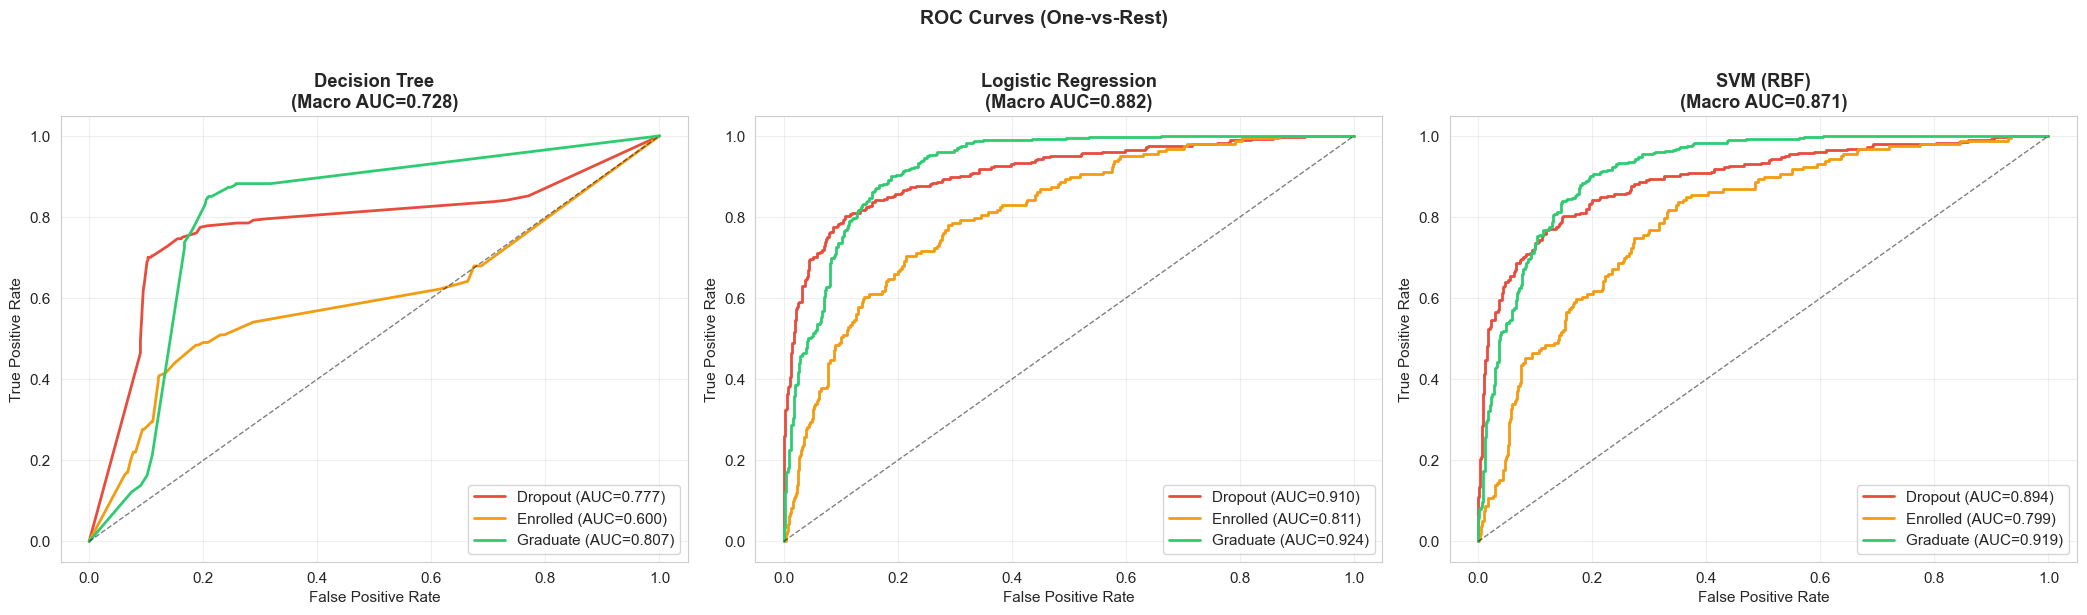

In [4]:
# 绘制 ROC 曲线 / Plot ROC curves
fig = plot_roc_curves(
    models, X_test.values, y_test.values,
    save_path=os.path.join(PLOT_DIR, "05_roc_curves.png"),
)
plt.show()

## 3. 交叉验证 (Cross-Validation)

使用 5-fold 交叉验证评估每个模型的泛化能力。在 train+val 合并集上进行 CV。
Evaluate generalization via 5-fold CV on the combined train+val set.

Decision Tree: F1(macro) = 0.6617 ± 0.0172
  Per-fold: ['0.6591', '0.6594', '0.6418', '0.6936', '0.6547']


Logistic Regression: F1(macro) = 0.6854 ± 0.0115
  Per-fold: ['0.6855', '0.6693', '0.6900', '0.7035', '0.6784']


SVM (RBF): F1(macro) = 0.6388 ± 0.0099
  Per-fold: ['0.6381', '0.6220', '0.6367', '0.6506', '0.6467']
图片已保存 / Plot saved to data/plots/05_cv_results.png


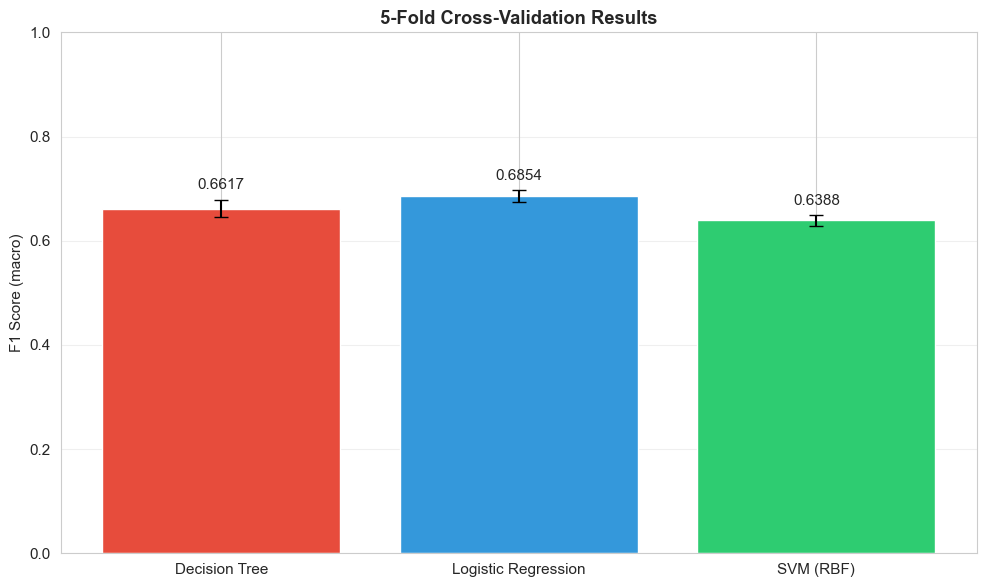

In [5]:
# 5-fold 交叉验证 / 5-fold cross-validation
cv_results = {}
for name in ["Decision Tree", "Logistic Regression", "SVM (RBF)"]:
    model_type = {"Decision Tree": "dt", "Logistic Regression": "lr", "SVM (RBF)": "svm"}[name]
    kwargs = {"max_depth": 10} if model_type == "dt" else {"max_iter": 5000} if model_type == "lr" else {"kernel": "rbf", "C": 10.0}
    fresh_model = get_model(model_type, **kwargs)
    cv_res = cross_validate_model(fresh_model, X_trainval.values, y_trainval.values, cv=5)
    cv_results[name] = cv_res
    print(f"{name}: F1(macro) = {cv_res['mean']:.4f} \u00b1 {cv_res['std']:.4f}")
    print(f"  Per-fold: {[f'{s:.4f}' for s in cv_res['scores']]}")

# 可视化 CV 结果 / Visualize CV results
fig, ax = plt.subplots(figsize=(10, 6))
models_list = list(cv_results.keys())
means = [cv_results[m]["mean"] for m in models_list]
stds = [cv_results[m]["std"] for m in models_list]
colors = ["#e74c3c", "#3498db", "#2ecc71"]

bars = ax.bar(models_list, means, yerr=stds, color=colors, edgecolor="white", capsize=5)
ax.set_ylabel("F1 Score (macro)")
ax.set_title("5-Fold Cross-Validation Results", fontweight="bold")
ax.set_ylim(0, 1)
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + s + 0.02,
            f"{m:.4f}", ha="center", fontsize=11)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "05_cv_results.png"), dpi=150, bbox_inches="tight")
print(f"\u56fe\u7247\u5df2\u4fdd\u5b58 / Plot saved to data/plots/05_cv_results.png")
plt.show()

## 4. 验证曲线分析 (Validation Curve Analysis)

通过验证曲线判断模型是否存在过拟合或欠拟合。
Use validation curves to diagnose overfitting or underfitting.

Plot saved to E:\Project\2011machine_learning\data\plots\05_valcurve_dt_depth.png


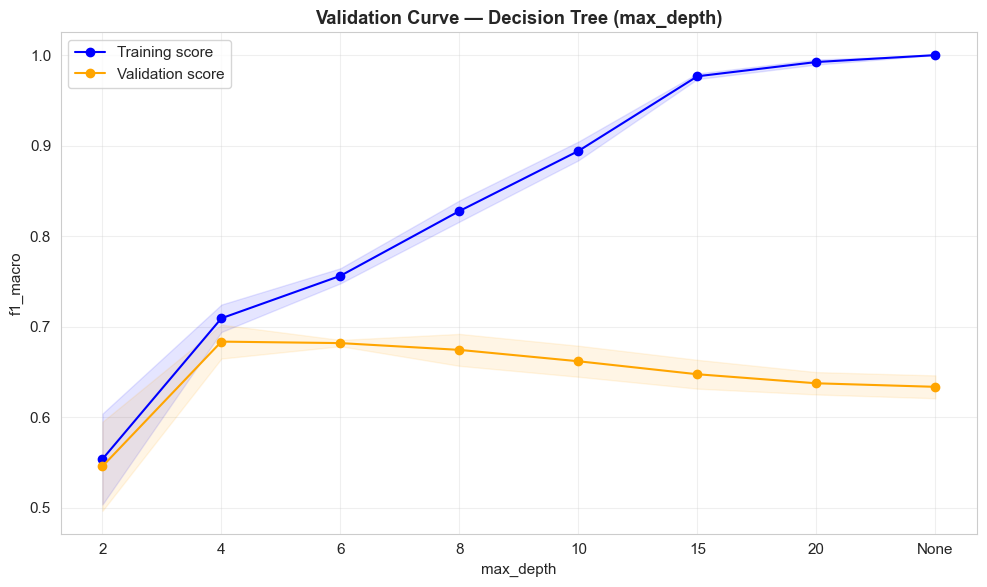

Plot saved to E:\Project\2011machine_learning\data\plots\05_valcurve_lr_c.png


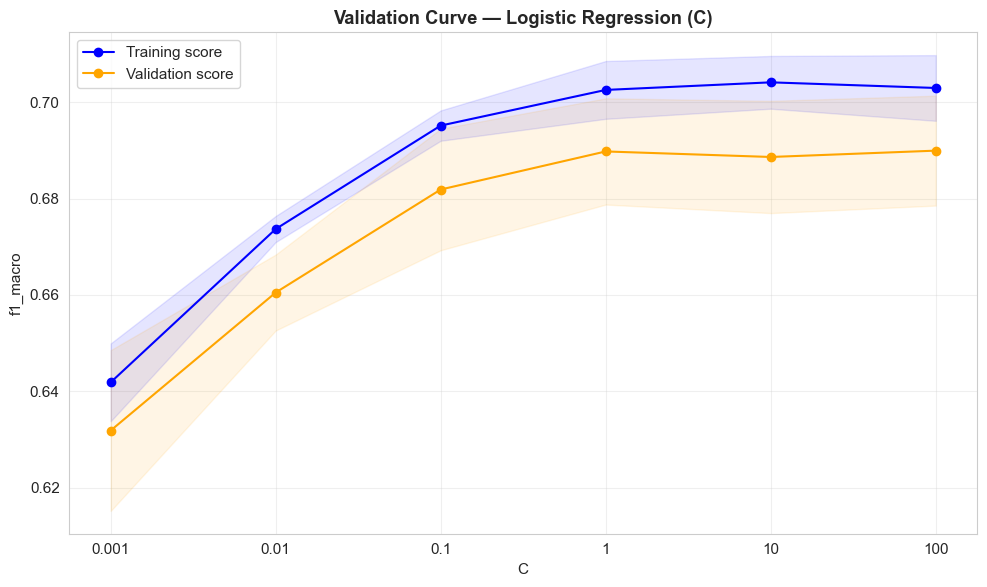

In [6]:
# Decision Tree: max_depth 验证曲线 / Decision Tree: max_depth validation curve
from sklearn.tree import DecisionTreeClassifier
plot_validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_trainval.values, y_trainval.values,
    param_name="max_depth", param_range=[2, 4, 6, 8, 10, 15, 20, None],
    title="Validation Curve \u2014 Decision Tree (max_depth)",
    save_path=os.path.join(PLOT_DIR, "05_valcurve_dt_depth.png"),
)
plt.show()

# Logistic Regression: C 验证曲线 / Logistic Regression: C validation curve
from sklearn.linear_model import LogisticRegression
plot_validation_curve(
    LogisticRegression(random_state=42, max_iter=1000),
    X_trainval.values, y_trainval.values,
    param_name="C", param_range=[0.001, 0.01, 0.1, 1, 10, 100],
    title="Validation Curve \u2014 Logistic Regression (C)",
    save_path=os.path.join(PLOT_DIR, "05_valcurve_lr_c.png"),
)
plt.show()

## 5. 学习曲线 (Learning Curves)

学习曲线展示训练集大小对模型性能的影响，帮助判断是否需要更多数据。
Learning curves show how training set size affects performance — helps determine if more data is needed.

Plot saved to E:\Project\2011machine_learning\data\plots\05_learning_curve_dt.png


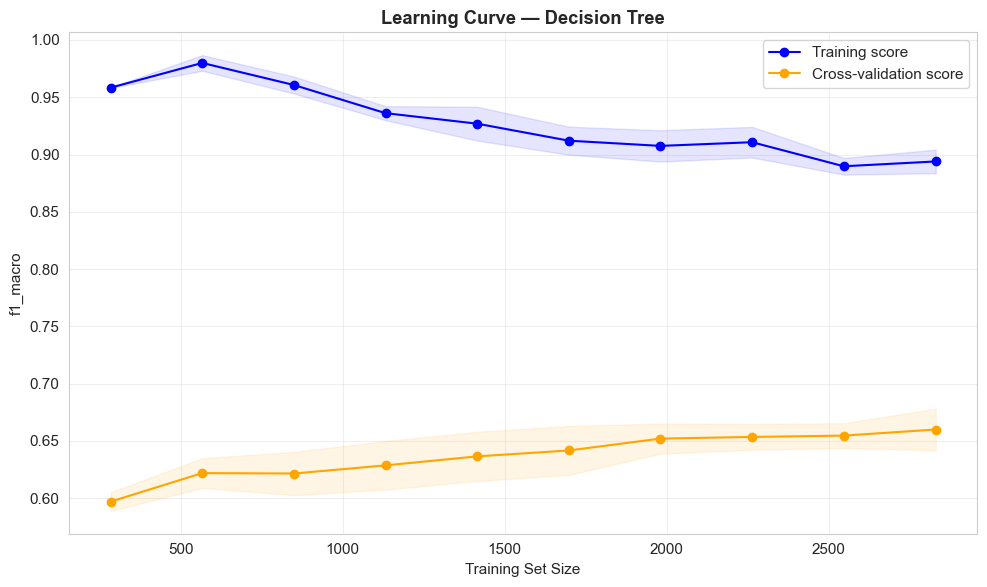

Plot saved to E:\Project\2011machine_learning\data\plots\05_learning_curve_lr.png


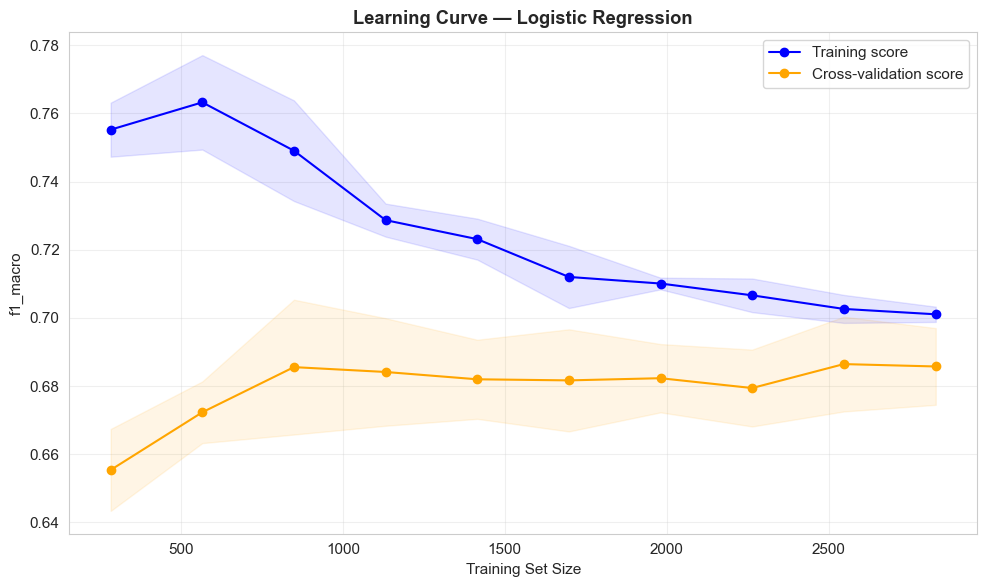

Plot saved to E:\Project\2011machine_learning\data\plots\05_learning_curve_svm.png


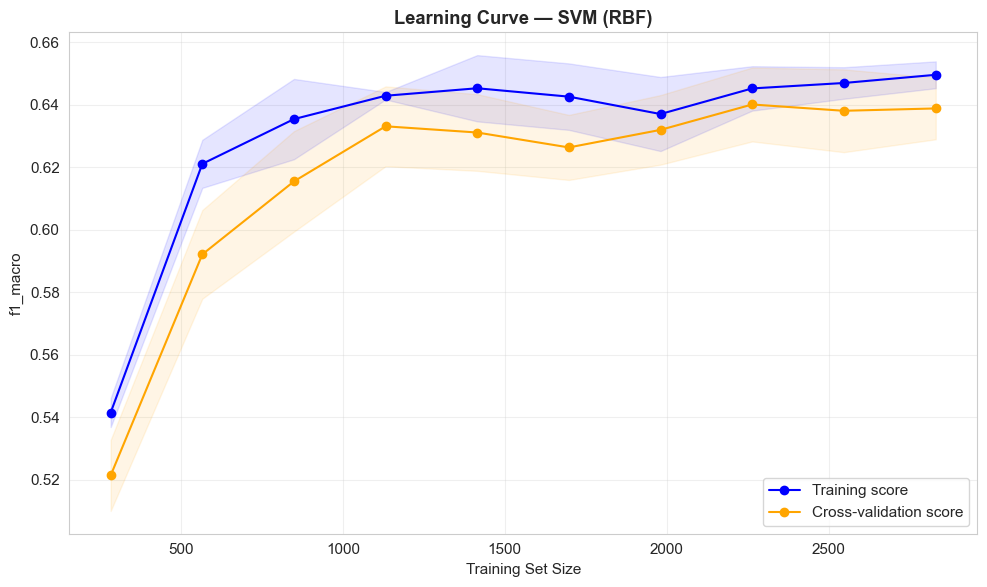

In [7]:
# 为每个模型绘制学习曲线 / Plot learning curve for each model
for name, model_type, kwargs in [
    ("Decision Tree", "dt", {"max_depth": 10}),
    ("Logistic Regression", "lr", {"max_iter": 5000}),
    ("SVM (RBF)", "svm", {"kernel": "rbf", "C": 10.0}),
]:
    model = get_model(model_type, **kwargs)
    plot_learning_curve(
        model, X_trainval.values, y_trainval.values,
        title=f"Learning Curve \u2014 {name}",
        save_path=os.path.join(PLOT_DIR, f"05_learning_curve_{model_type}.png"),
    )
    plt.show()

## 6. 综合讨论 (Comprehensive Discussion)

### 模型性能分析 / Model Performance Analysis (100-200 words)

基于上述评估结果，我们对三种模型的表现进行综合分析：

**Decision Tree** 在训练集上表现出色但测试集性能显著下降，验证曲线显示随  增大训练/验证分数差距扩大，这是典型的过拟合信号。通过限制树深度（如 max_depth=10）可以缓解，但泛化能力仍受限。

**Logistic Regression** 作为线性模型，训练集和测试集表现较为一致，泛化能力最为稳定。在三个基础模型中，LR 在测试集上取得了最佳的 F1 分数，表明在本数据集上线性决策边界已经能捕捉到大部分类别信息。

**SVM (RBF)** 通过核函数具备捕获非线性模式的潜力，但其性能高度依赖超参数 (C, gamma) 的选择。通过增大正则化参数 C，SVM 的性能得到显著改善，但仍需通过验证曲线仔细调优以避免过拟合或欠拟合。

三种模型在 Enrolled 类别上的 recall 普遍较低，这与该类别样本最少（18%）有关，是类别不平衡的直接表现。后续可通过类别权重调整（class_weight）或采样策略来改善。

Based on the evaluation results, we provide a comprehensive analysis of the three models. Decision Tree shows strong training performance but clear overfitting signals in validation curves. Logistic Regression provides the most stable generalization among the three baselines and achieves the best test F1 score, demonstrating that linear boundaries capture most class information in this dataset. SVM (RBF) has potential for nonlinear pattern capture but is highly sensitive to hyperparameter tuning (C, gamma). All models struggle with the minority Enrolled class (only 18% of samples), suggesting that class-weight balancing or resampling strategies could improve performance.